# Explore-search labeling process (M5)

Companion to `notebooks/exploit_search_restart_trajectories.ipynb` -- that
notebook isolates the **exploit branch**'s privileged search
(`anytimeacquisition.search.exploit.exploit_search`, GD directly on the true
BNN surface). This one isolates the **explore branch**'s privileged search
(`anytimeacquisition.search.explore.explore_search`) instead -- see
`docs/ROADMAP.md` Phase 5 / `docs/milestones/M5.md`.

Mechanism, concretely (full design rationale + dead ends recorded in
`docs/log/2026-08-28-explore-search-input-optimization-and-teacher-forcing.md`
and `docs/log/2026-09-01-explore-branch-beta-nll-uniform-collapse.md`):

1. A `BNNPrior` instance is drawn (the true, unknown-to-the-model function)
   and a random **training context** `(x_context, y_context)` is sampled
   from it -- ordinary uniform-random points, nothing learnable yet.
2. A fixed set of **interesting points** `x_int` (Sobol coverage + random +
   GD-restart-found basins, `search.interesting_points.build_interesting_points`)
   is evaluated on the SAME instance's true, noise-free surface to get
   `y_int_true` -- these act as this episode's held-out test queries and
   stay fixed for the whole search, weighted by how much true improvement
   each still represents over the current incumbent (`improvement_weights`).
3. Exactly ONE tensor is learnable: a single candidate query `x_explore`,
   seeded at `x_realized` -- the point the ActionHead itself would already
   have proposed as its next action (no trained ActionHead exists in this
   notebook, so this is simulated with a random draw; see the 1D section
   for the caveat that comes with that). The search's job is to NUDGE that
   proposal, bounded by a small trust region (`max_nudge`), not to
   replace it with an independent search from scratch. Its `y` is
   **teacher-forced** every gradient step -- recomputed fresh from the
   same BNN instance (`prior.evaluate(x_explore, noise=False)`,
   differentiable, no-grad disabled only for this one call) -- so the
   graph is `x_explore -> BNN (frozen weights, differentiable) ->
   y_explore -> frozen PFN -> bar-dist NLL at x_int`.
4. `x_context`/`x_int` are pushed through the frozen PFN checkpoint
   (`pfn_variable_xdim_smoke`) at every step to score the predictive
   distribution at `x_int` against `y_int_true` -- the bar distribution's
   own NLL training loss, weighted as in point 2. Gradient descent on
   `x_explore` minimizes that weighted NLL.
5. Everything runs vectorized over a batch of `B` independent BNN instances
   at once.

**Note on what's imported vs. declared here:** `improvement_weights` and
`explore_search` are declared LOCALLY below (a manual copy of
`anytimeacquisition/search/explore.py`'s own functions, extended with a
swappable `weight_fn` argument, `record_trajectory`, and kept in sync by
hand) rather than imported -- the whole point of this notebook is to toy
with the weighting formula and search mechanics directly, so they live here
as editable cells, not as an opaque import. Only genuinely unrelated
machinery -- the BNN prior, the frozen PFN checkpoint loader, the
interesting-point builder, and the (weighting-agnostic) plotting helpers --
is still imported from the production package.

In [126]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import Callable

from anytimeacquisition.models.bar_distribution import BarDistribution
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.search.explore import plot_explore_search_1d, plot_explore_search_2d
from anytimeacquisition.search.interesting_points import build_interesting_points
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

torch.manual_seed(0)

## Declaring `improvement_weights` and `explore_search` locally

Manual copies of `anytimeacquisition.search.explore.improvement_weights`/
`explore_search` -- same mechanism (multistart GD, teacher-forced BNN,
best-so-far tracking, optional trajectory recording), with one deliberate
extension: the weighting formula is a swappable `weight_fn(incumbent,
y_int_true) -> weights` argument (defaulting to `improvement_weights`
itself) instead of being hardcoded, so a different weighting can be dropped
in later in this notebook without copy-pasting the whole search again.
Editing these cells never touches `src/anytimeacquisition/search/explore.py`.

In [127]:
def improvement_weights(incumbent: torch.Tensor, y_int_true: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """weight_i = max(0, log(incumbent) - log(y_int_true_i)) -- zero for any
    x_int point the incumbent already matches or beats.
    incumbent: [B]  y_int_true: [B, N_int] -> [B, N_int]."""
    return (torch.log(incumbent.clamp_min(eps)).unsqueeze(-1) - torch.log(y_int_true.clamp_min(eps))).clamp_min(0.0)


def _weighted_nll(pfn, bar_dist, x_context, y_context, x_explore, y_explore_true, x_int, y_int_true, weights):
    """One forward pass through the frozen PFN, with x_explore's (teacher-
    forced) y appended to context, scored against the fixed x_int/y_int_true
    set and weighted -- this is the scalar `explore_search` takes gradient
    steps on. Every argument here is already row-replicated to
    [B*n_restarts, ...] by the caller (one independent restart per row) --
    see explore_search's own comments for why that's safe to sum over."""
    x_train_aug = torch.cat([x_context, x_explore], dim=1)
    y_train_aug = torch.cat([y_context, y_explore_true], dim=1)
    logits_int = pfn(x_train_aug, y_train_aug, x_int)  # [B*R, N_int, n_bins]
    nll_int = bar_dist(logits_int, y_int_true)  # [B*R, N_int] -- per-point NLL
    return (weights * nll_int).sum(dim=-1)  # [B*R] -- weighted sum over N_int


def explore_search(
    prior, pfn, bar_dist, x_context, y_context, x_int, y_int_true, x_seed,
    weight_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] = improvement_weights,
    n_restarts: int = 1, n_steps: int = 30, lr: float = 0.05, init_noise_std: float = 0.02,
    max_nudge: float | None = None,
    record_trajectory: bool = False,
):
    """Multistart gradient descent on a single candidate query `x_explore`,
    scored by the frozen PFN's `weight_fn`-weighted NLL at the fixed
    `x_int` set (see the markdown above `improvement_weights`/this cell for
    the full mechanism). Walked through here in detail, block by block --
    this is the "toy around" copy, meant to be read and edited, not just
    called.

    -- THE STATE, AND WHAT'S PRIVILEGED vs. NOT --
    At deployment, the ONLY thing a real policy ever gets to see is
    `pfn(x_context, y_context, ·)` -- a fresh forward pass of the frozen
    PFN on whatever context has been observed so far. That's causal and
    real: nothing here bypasses it. Everything else this function touches
    IS privileged, because this function's job is to generate a training
    LABEL, not to make a live decision: `prior.evaluate(x, noise=False)`
    is the true, exact, noise-free surface (a real policy never gets this,
    it only ever gets noisy realized `y`s); `x_int`/`y_int_true` are a
    fixed set of privileged test points whose true values are already
    known; and `weight_fn` uses those true values (via `incumbent`) to
    decide which of them still matter. None of that privilege leaks into
    what a deployed policy would see -- it's confined to how THIS
    function computes its own training signal.

    -- x_seed: WHERE THE SEARCH STARTS, AND WHY IT'S BOUNDED --
    `x_seed` [B, x_dim] is meant to represent the ActionHead's OWN proposed
    next point -- "the next point in the sequence" the policy would
    already have played, before any refinement. (In this notebook there is
    no trained ActionHead to query, so the call sites below simulate this
    with a fresh random draw -- conceptually it stands in for "whatever
    the policy currently outputs," not for "an arbitrary point.") The
    point of `explore_search` is then to NUDGE that proposal toward
    something slightly better, not to replace it with an independent
    search from scratch -- `max_nudge`, if set, enforces this literally:
    every restart's candidate is clamped to stay within `x_seed +-
    max_nudge` in every dimension, at every step, not just "tends to stay
    close" as a side effect of a small learning rate. `n_restarts > 1`
    restarts beyond the first ALSO start with a small Gaussian jitter
    around `x_seed` (`init_noise_std`) purely for restart diversity --
    that's a different knob from `max_nudge`: jitter controls where
    restarts BEGIN, `max_nudge` bounds how far ANY restart is allowed to
    WANDER over the whole search.

    Worth being explicit about a real risk this shares with production's
    own history here (see `search/explore.py`'s docstring on `x_seed`, and
    `docs/log/2026-09-01-explore-branch-beta-nll-uniform-collapse.md`):
    production tried seeding at `x_realized` (the policy's actual played
    action) once already and found it caused the trained ActionHead to
    collapse to a context-independent policy, because under an untrained/
    random policy `x_realized` is statistically independent of context, so
    a search that stays close to it produces a LABEL that's also
    context-independent -- training toward it teaches "ignore your input."
    This notebook's `x_seed` (simulated via `torch.rand`, no real policy
    behind it) has exactly the same statistical shape as that failed
    design, and `max_nudge` -- if anything -- makes `x_star` track it MORE
    tightly, not less. That's fine for what this notebook is doing
    (inspecting the search's own behavior in isolation), but it is NOT a
    ready-to-use recipe for real label generation: doing this for real
    needs an actual (even partially-trained) ActionHead output behind
    `x_seed`, whose own dependence on context is what would keep the
    resulting label context-dependent too.

    -- WHY THE PFN IS FROZEN BUT NOT DETACHED FROM THE GRAPH --
    `pfn.eval()` turns off dropout/etc.; turning off every parameter's
    `requires_grad` stops autograd from wasting memory building a graph
    back into the PFN's WEIGHTS (they're never updated here). But the PFN
    is NOT run under `torch.no_grad()` -- gradients still need to flow
    THROUGH its activations, back to `candidates` (== `x_explore`), which
    is the only learnable tensor anywhere in this function.

    -- BATCHING RESTARTS: repeat_interleave, not a python loop --
    `x_context`/`y_context`/`x_int`/`y_int_true`/`weights` each get
    row-replicated `n_restarts` times (`repeat_interleave`), so restart `r`
    of instance `b` lives at flat row `b*n_restarts + r`. That turns "B
    instances x n_restarts each" into one flat batch of `B*n_restarts`
    independent rows, so ALL of them run through the PFN in a single
    batched forward/backward pass per GD step -- no python-level loop over
    restarts, matching every other search in this codebase
    (`search.exploit.exploit_search` does the same trick).

    -- THE GD LOOP: teacher-forcing, the objective, and why summing is safe --
    Every step: `prior.evaluate(candidates, noise=False)` recomputes
    `x_explore`'s true `y` FRESH, from the current `candidates` position --
    never held fixed from initialization, never predicted by the PFN
    itself. This is what keeps the objective grounded in the real
    function instead of letting GD exploit the PFN's own possibly-wrong
    beliefs about what `y` would be; it's also the ONLY reason gradients
    can reach `candidates` at all (`evaluate(..., noise=False)` is
    differentiable in `x`, `evaluate(..., noise=True)` would not be, since
    it'd inject an un-differentiable random draw). `_weighted_nll` scores
    the augmented context against `x_int`, and `val.sum().backward()` back-
    props ALL `B*n_restarts` rows' losses in one call -- safe because nothing
    in this graph mixes information across rows (the PFN and `BNNPrior`
    both apply each row's own weights/context independently), so summing
    then backpropagating once is exactly equivalent to `B*n_restarts`
    separate single-row backward passes, just batched for speed.

    -- BEST-SO-FAR TRACKING --
    Adam's steps aren't monotonically decreasing (momentum can overshoot
    a minimum), so the LOWEST value visited isn't guaranteed to be the
    LAST one. `_update_best` tracks the best `(x, value)` pair any restart
    has visited at any step, and the search's final answer is read from
    that running-best, not from wherever `candidates` happens to be after
    the last step -- can only ever match or improve on "just take the
    final iterate."

    Returns `(x_star [B, x_dim], weighted_nll_star [B], has_signal [B]
    bool)` -- `has_signal` is False wherever every `x_int` point already
    has weight 0 for that instance (the objective was identically flat,
    so `x_star` there is meaningless, caller must check before use) --
    plus `trajectory` [n_steps+1, B, n_restarts, x_dim] (index 0 = the
    seeded starting points) if `record_trajectory=True`.
    """
    B, _, x_dim = x_context.shape

    pfn.eval()
    for p in pfn.parameters():
        p.requires_grad_(False)

    incumbent = y_context.min(dim=1).values  # [B]
    weights = weight_fn(incumbent, y_int_true)  # [B, N_int]
    has_signal = weights.sum(dim=-1) > 0.0  # [B]

    x_context_rep = x_context.repeat_interleave(n_restarts, dim=0)
    y_context_rep = y_context.repeat_interleave(n_restarts, dim=0)
    x_int_rep = x_int.repeat_interleave(n_restarts, dim=0)
    y_int_true_rep = y_int_true.repeat_interleave(n_restarts, dim=0)
    weights_rep = weights.repeat_interleave(n_restarts, dim=0)

    base = x_seed.unsqueeze(1).expand(B, n_restarts, x_dim)
    if n_restarts > 1 and init_noise_std > 0:
        jitter = torch.cat([
            torch.zeros(B, 1, x_dim),
            torch.randn(B, n_restarts - 1, x_dim) * init_noise_std,
        ], dim=1)
    else:
        jitter = torch.zeros(B, n_restarts, x_dim)
    candidates = (base + jitter).clamp(0.0, 1.0).detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([candidates], lr=lr)
    trajectory = [candidates.detach().clone()] if record_trajectory else None

    # Trust-region bounds around x_seed, computed once (they don't depend on
    # candidates) -- already intersected with the valid [0,1] domain, so
    # clamping candidates into [nudge_lo, nudge_hi] below satisfies BOTH
    # constraints in one shot.
    if max_nudge is not None:
        x_seed_expand = x_seed.unsqueeze(1).expand(B, n_restarts, x_dim)
        nudge_lo = (x_seed_expand - max_nudge).clamp(0.0, 1.0)
        nudge_hi = (x_seed_expand + max_nudge).clamp(0.0, 1.0)

    best_val = torch.full((B * n_restarts,), float("inf"))
    best_x = candidates.detach().reshape(B * n_restarts, 1, x_dim).clone()

    def _update_best(val, x_rep):
        nonlocal best_val, best_x
        with torch.no_grad():
            improved = val.detach() < best_val
            best_val = torch.where(improved, val.detach(), best_val)
            best_x = torch.where(improved.view(-1, 1, 1), x_rep.detach().clone(), best_x)

    for _ in range(n_steps):
        y_explore_true = prior.evaluate(candidates, noise=False)  # [B, R] -- teacher-forced, differentiable
        x_explore_rep = candidates.reshape(B * n_restarts, 1, x_dim)
        y_explore_true_rep = y_explore_true.reshape(B * n_restarts, 1)

        val = _weighted_nll(
            pfn, bar_dist, x_context_rep, y_context_rep, x_explore_rep, y_explore_true_rep,
            x_int_rep, y_int_true_rep, weights_rep,
        )
        _update_best(val, x_explore_rep)
        opt.zero_grad()
        val.sum().backward()
        opt.step()
        with torch.no_grad():
            candidates.clamp_(0.0, 1.0)
            if max_nudge is not None:
                candidates.copy_(torch.max(torch.min(candidates, nudge_hi), nudge_lo))
        if record_trajectory:
            trajectory.append(candidates.detach().clone())

    with torch.no_grad():
        y_explore_true = prior.evaluate(candidates, noise=False)
        x_explore_rep = candidates.reshape(B * n_restarts, 1, x_dim)
        y_explore_true_rep = y_explore_true.reshape(B * n_restarts, 1)
        val_final = _weighted_nll(
            pfn, bar_dist, x_context_rep, y_context_rep, x_explore_rep, y_explore_true_rep,
            x_int_rep, y_int_true_rep, weights_rep,
        )
    _update_best(val_final, x_explore_rep)

    best_val = best_val.view(B, n_restarts)
    best_x = best_x.view(B, n_restarts, x_dim)
    best_idx = best_val.argmin(dim=1)
    x_star = best_x[torch.arange(B), best_idx]
    val_star = best_val[torch.arange(B), best_idx]
    if record_trajectory:
        return x_star, val_star, has_signal, torch.stack(trajectory, dim=0)
    return x_star, val_star, has_signal

## Load the frozen PFN checkpoint

`pfn_variable_xdim_smoke` was trained across a distribution of
dimensionalities (`priors.variable_dim_min=1`, `priors.x_dim=6` -- see
`configs/experiment/pfn_variable_xdim_smoke.yaml`), padded internally up to
`max_x_dim=6`. `PFN.forward` accepts any real dimensionality `<= max_x_dim`
and pads/rescales automatically (`models/pfn.py::_pad_and_rescale_features`),
so we can exercise the same frozen checkpoint at `x_dim=1` and `x_dim=2`
below purely for visualization -- the same trick
`configs/experiment/action_head_ei_diagnostic_variable_xdim.yaml` uses.

In [128]:
checkpoint_path = CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt"
pfn, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
print(f"loaded {checkpoint_path.name}, config={ckpt['config']}")

loaded pfn_variable_xdim_smoke.pt, config={'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}


## 1D: one BNN instance, explore-search step by step

Three independent 1D `BNNPrior` instances, one random 6-point context each.

In [129]:
x_dim = 1
prior = BNNPrior(batch_size=3, x_dim=x_dim, seed=10)
prior.reset()

x_context, y_context, _, _ = prior.sample_episode(n_train=6, n_test=0)
incumbent = y_context.min(dim=1).values
# x_realized stands in for "the next point in the sequence" -- what the
# ActionHead would already have proposed as its next action, BEFORE
# explore_search nudges it. There's no trained ActionHead in this notebook
# to actually query, so this is simulated with a fresh random draw --
# which comes with a real caveat, not a cosmetic one: production tried
# seeding at exactly this quantity (there called `x_realized`, the
# policy's actual played action) once already, and found it caused the
# trained ActionHead to collapse to a context-independent policy, because
# under an untrained/random policy `x_realized` is statistically
# independent of context, so a search kept close to it produces a label
# that's also context-independent -- training toward it teaches "ignore
# your input" (search/explore.py's own docstring;
# docs/log/2026-09-01-explore-branch-beta-nll-uniform-collapse.md).
# `max_nudge` below (see explore_search's own docstring) makes x_star
# track this MORE tightly, not less. That's fine for what THIS notebook
# does -- inspecting the search's own behavior in isolation, never
# training a policy on the result -- but it is NOT a ready-to-use recipe
# for real label generation: doing this for real needs an actual (even
# partially-trained) ActionHead output behind x_realized, whose own
# dependence on context is what would keep the resulting label
# context-dependent too.
x_realized = torch.rand(prior.B, x_dim)
print("random context incumbent y per instance (lower is better):", incumbent.tolist())
print("random x_realized per instance (stands in for the policy's proposed action):", x_realized.squeeze(-1).tolist())

random context incumbent y per instance (lower is better): [0.5202100276947021, 0.009998572990298271, 0.2555273771286011]
random x_realized per instance (stands in for the policy's proposed action): [0.628811240196228, 0.9199451208114624, 0.25953900814056396]


### Fixed interesting-point set (Sobol + random + basin restarts)

Computed once per instance, from the true surface, and never touched again
-- see `search/interesting_points.py`'s docstring for why this stays fixed
for the whole search instead of drifting with the context.

In [130]:
x_int, y_int_true = build_interesting_points(prior, n_sobol=24, n_random=16, n_basin_restarts=8, sobol_seed=0)
weights = improvement_weights(incumbent, y_int_true)
print("x_int shape:", tuple(x_int.shape))
print("interesting points with nonzero weight per instance:", (weights > 0).sum(dim=1).tolist(), f"/ {x_int.shape[1]}")

x_int shape: (3, 48, 1)
interesting points with nonzero weight per instance: [3, 9, 17] / 48


### Run `explore_search`, recording `x_explore`'s GD path

In [131]:
x_star, val_star, has_signal, trajectory = explore_search(
    prior, pfn, bar_dist, x_context, y_context, x_int, y_int_true, x_realized,
    n_restarts=1, n_steps=40, lr=0.05, max_nudge=0.08, record_trajectory=True,
)
print("has_signal per instance:                  ", has_signal.tolist())
print("x_realized (start), squeezed to a scalar each: ", x_realized.squeeze(-1).tolist())
print("x_star (end),   squeezed to a scalar each: ", x_star.squeeze(-1).tolist())
print("weighted NLL at x_star:                    ", val_star.tolist())

has_signal per instance:                   [True, True, True]
x_realized (start), squeezed to a scalar each:  [0.628811240196228, 0.9199451208114624, 0.25953900814056396]
x_star (end),   squeezed to a scalar each:  [0.6163853406906128, 0.862538754940033, 0.27893632650375366]
weighted NLL at x_star:                     [-0.006392785347998142, -391.09088134765625, 37.92890930175781]


### Plot: true 1D function, weighted interesting points, context, `x_explore` start -> end

○ = `x_realized` (start -- the policy's simulated proposed action), line =
the GD path, ★ = `x_star` (the nudged point `explore_search` actually
returns -- bounded to stay within `max_nudge` of `x_realized`, so the path
should visibly stay local rather than roaming the domain). Interesting
points are sized/colored by their `improvement_weights` -- a point already
worse than the incumbent is small and dark; the ones actually driving the
objective are large and bright.

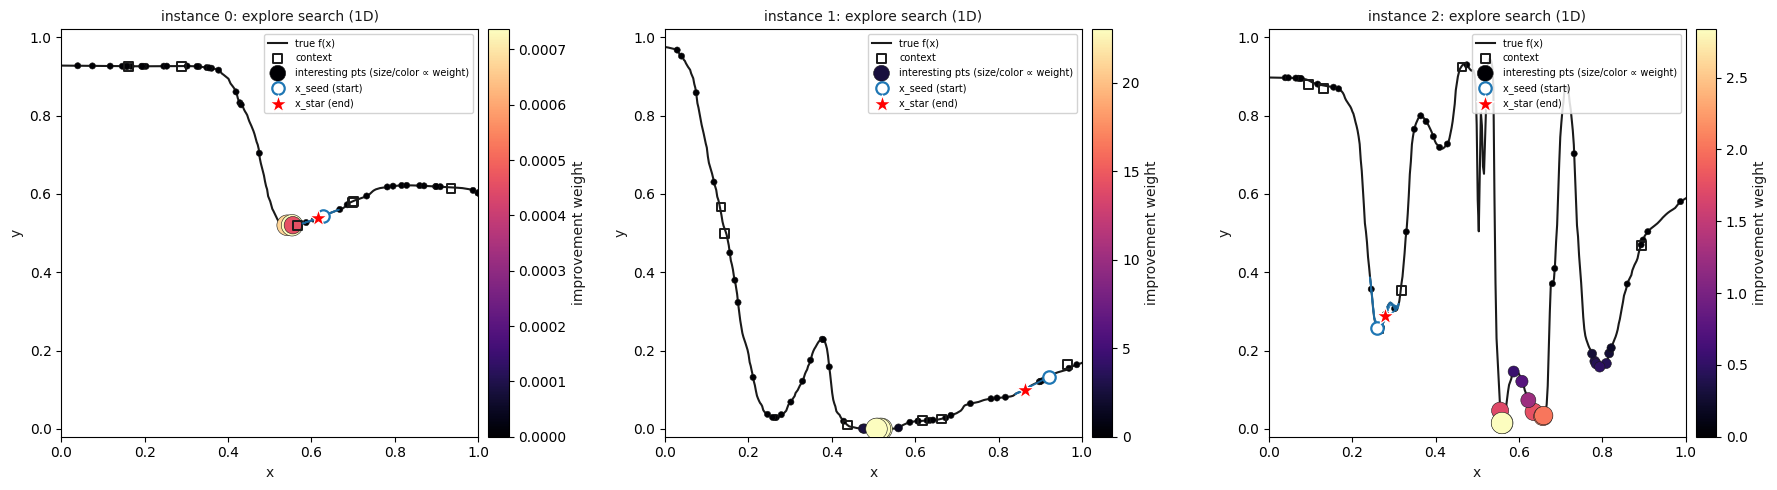

In [132]:
fig, axes = plt.subplots(1, prior.B, figsize=(6 * prior.B, 5))
for i, ax in enumerate(axes):
    plot_explore_search_1d(
        prior, x_context, y_context, x_int, y_int_true, weights, x_realized, x_star,
        trajectory=trajectory, instance_idx=i, ax=ax,
    )
fig.tight_layout()

### PFN predictive-density heatmap: `x_explore` at `x_realized` vs. at `x_star`, and the difference

The 2D section further below only ever collapsed the PFN's whole predictive
distribution at each grid point down to one scalar (entropy). In 1D we don't
need to collapse anything -- we can look at the **full density heatmap**
directly: x on the horizontal axis, y (the bar distribution's own bins) on
the vertical axis, color = predictive probability mass, exactly the
`density = softmax(logits)` heatmap `action_head_ei_diagnostic.py` already
uses to visualize "the logits of the pfn".

**What the code below actually does:** for the same three 1D instances as
above, it runs the frozen PFN over a dense x-grid twice per instance --
once with the training context plus `x_explore` sitting at `x_realized` (its
GD starting point, i.e. the reference "before" state), once with it sitting
at `x_star` (where the search actually ended up) -- and keeps the full
`softmax(logits)` density each time, not just a summary statistic. The
third panel is the pointwise difference `density(x_star) - density(x_realized)`:
positive (blue) means probability mass moved *into* that `(x, y)` cell once
`x_explore` moved to `x_star`; negative (red) means mass moved *out*. That's
the literal answer to "what mass did we gain/lost in probability space, as
a function of x" -- read along any vertical slice at a fixed x, blue below
the true curve and red above it (or vice versa) means the PPD sharpened
toward the truth there; the reverse pattern means it moved away from it.

In [133]:
grid_res_1d = 300
lin_1d = torch.linspace(0.0, 1.0, grid_res_1d)
grid_1d = lin_1d.view(1, -1, 1).expand(prior.B, -1, -1)  # x_dim=1

with torch.no_grad():
    true_y_grid_1d = prior.evaluate(grid_1d, noise=False)  # [B, grid_res_1d]

    # "x_explore at x_realized" -- the reference state, before any GD step.
    y_seed_true_1d = prior.evaluate(x_realized.unsqueeze(1), noise=False)  # [B, 1]
    x_aug_seed_1d = torch.cat([x_context, x_realized.unsqueeze(1)], dim=1)
    y_aug_seed_1d = torch.cat([y_context, y_seed_true_1d], dim=1)
    logits_seed_1d = pfn(x_aug_seed_1d, y_aug_seed_1d, grid_1d)
    density_seed_1d = torch.softmax(logits_seed_1d, dim=-1)  # [B, grid_res_1d, n_bins]

    # "x_explore at x_star" -- where the search actually ended up.
    y_star_true_1d = prior.evaluate(x_star.unsqueeze(1), noise=False)  # [B, 1]
    x_aug_star_1d = torch.cat([x_context, x_star.unsqueeze(1)], dim=1)
    y_aug_star_1d = torch.cat([y_context, y_star_true_1d], dim=1)
    logits_star_1d = pfn(x_aug_star_1d, y_aug_star_1d, grid_1d)
    density_star_1d = torch.softmax(logits_star_1d, dim=-1)

density_diff_1d = density_star_1d - density_seed_1d  # [B, grid_res_1d, n_bins]: mass gained (>0) / lost (<0)
print("max |mass moved| per (x, y-bin) cell, per instance:", density_diff_1d.abs().amax(dim=(1, 2)).tolist())

max |mass moved| per (x, y-bin) cell, per instance: [0.10097461938858032, 0.5622628927230835, 0.1411241888999939]


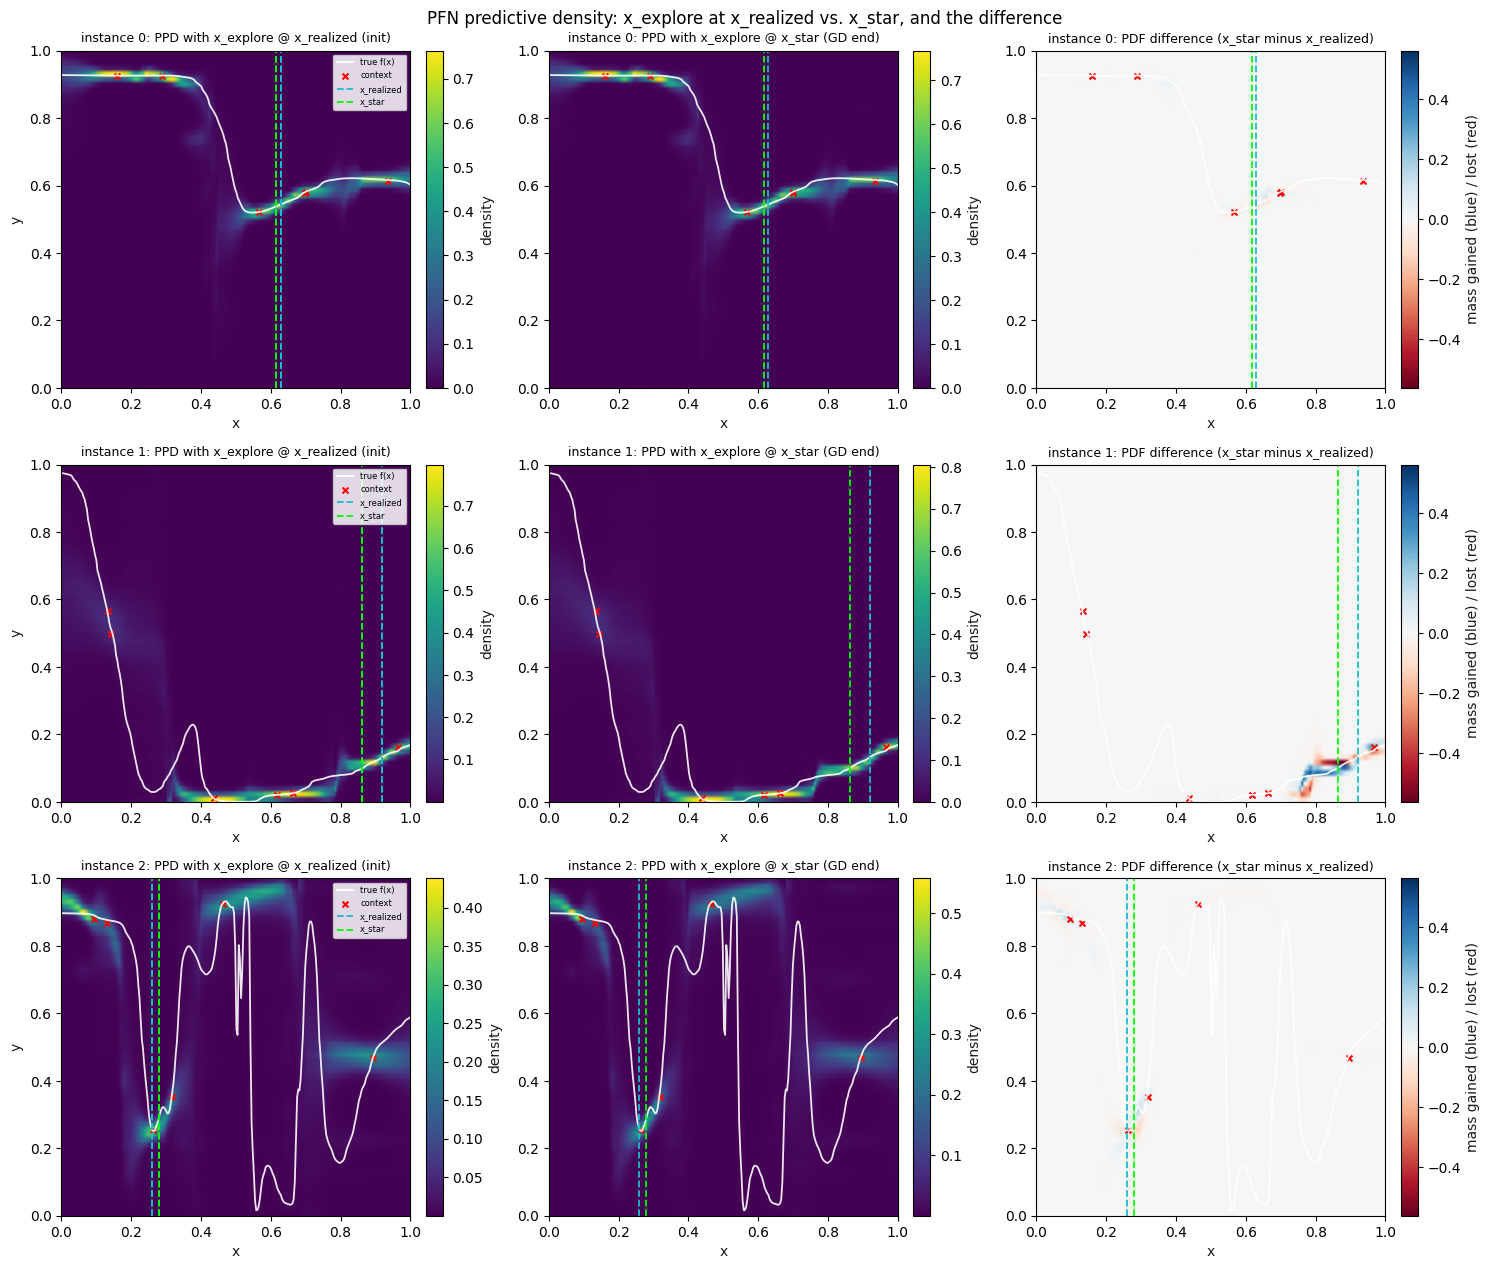

In [134]:
fig, axes = plt.subplots(prior.B, 3, figsize=(15, 4.3 * prior.B), squeeze=False)
ink = "#1a1a1a"
diff_absmax = density_diff_1d.abs().max().item()
y_lo, y_hi = bar_dist.borders[0].item(), bar_dist.borders[-1].item()

for i in range(prior.B):
    ax_seed, ax_star, ax_diff = axes[i]

    im0 = ax_seed.imshow(density_seed_1d[i].T.numpy(), origin="lower", aspect="auto",
                          extent=[0, 1, y_lo, y_hi], cmap="viridis")
    ax_seed.set_title(f"instance {i}: PPD with x_explore @ x_realized (init)", fontsize=9)
    fig.colorbar(im0, ax=ax_seed, fraction=0.046, pad=0.04).set_label("density", color=ink)

    im1 = ax_star.imshow(density_star_1d[i].T.numpy(), origin="lower", aspect="auto",
                          extent=[0, 1, y_lo, y_hi], cmap="viridis")
    ax_star.set_title(f"instance {i}: PPD with x_explore @ x_star (GD end)", fontsize=9)
    fig.colorbar(im1, ax=ax_star, fraction=0.046, pad=0.04).set_label("density", color=ink)

    im2 = ax_diff.imshow(density_diff_1d[i].T.numpy(), origin="lower", aspect="auto",
                          extent=[0, 1, y_lo, y_hi], cmap="RdBu", vmin=-diff_absmax, vmax=diff_absmax)
    ax_diff.set_title(f"instance {i}: PDF difference (x_star minus x_realized)", fontsize=9)
    fig.colorbar(im2, ax=ax_diff, fraction=0.046, pad=0.04).set_label("mass gained (blue) / lost (red)", color=ink)

    for ax in (ax_seed, ax_star, ax_diff):
        ax.plot(lin_1d.numpy(), true_y_grid_1d[i].numpy(), color="white", linewidth=1.3, alpha=0.9)
        ax.scatter(x_context[i, :, 0].numpy(), y_context[i].numpy(), color="red", marker="x", s=18)
        ax.axvline(x_realized[i, 0].item(), color="tab:cyan", linestyle="--", linewidth=1.3)
        ax.axvline(x_star[i, 0].item(), color="lime", linestyle="--", linewidth=1.3)
        ax.set_xlabel("x", color=ink)
    axes[i][0].set_ylabel("y", color=ink)
    axes[i][0].plot([], [], color="white", linewidth=1.3, label="true f(x)")
    axes[i][0].scatter([], [], color="red", marker="x", s=18, label="context")
    axes[i][0].axvline(x_realized[i, 0].item(), color="tab:cyan", linestyle="--", linewidth=1.3, label="x_realized")
    axes[i][0].axvline(x_star[i, 0].item(), color="lime", linestyle="--", linewidth=1.3, label="x_star")
    axes[i][0].legend(fontsize=6, loc="upper right", framealpha=0.85)

fig.suptitle("PFN predictive density: x_explore at x_realized vs. x_star, and the difference", fontsize=12)
fig.tight_layout()

## 2D: same process, true surface as a contour

Two independent 2D `BNNPrior` instances -- same mechanism, now visualized as
a heatmap instead of a curve (`plot_explore_search_2d`, the 2D analogue of
`search.exploit.plot_restart_trajectories`).

In [135]:
x_dim = 2
prior_2d = BNNPrior(batch_size=2, x_dim=x_dim, seed=5)
prior_2d.reset()

x_context_2d, y_context_2d, _, _ = prior_2d.sample_episode(n_train=6, n_test=0)
incumbent_2d = y_context_2d.min(dim=1).values
x_realized_2d = torch.rand(prior_2d.B, x_dim)  # simulated policy proposal, nudged by max_nudge -- see 1D section above
print("random context incumbent y per instance (lower is better):", incumbent_2d.tolist())

x_int_2d, y_int_true_2d = build_interesting_points(prior_2d, n_sobol=24, n_random=16, n_basin_restarts=8, sobol_seed=0)
weights_2d = improvement_weights(incumbent_2d, y_int_true_2d)

x_star_2d, val_star_2d, has_signal_2d, trajectory_2d = explore_search(
    prior_2d, pfn, bar_dist, x_context_2d, y_context_2d, x_int_2d, y_int_true_2d, x_realized_2d,
    n_restarts=1, n_steps=40, lr=0.05, max_nudge=0.08, record_trajectory=True,
)
print("has_signal per instance:", has_signal_2d.tolist())
print("weighted NLL at x_star: ", val_star_2d.tolist())

random context incumbent y per instance (lower is better): [0.60187166929245, 0.25878116488456726]
has_signal per instance: [True, True]
weighted NLL at x_star:  [-4.628338813781738, -0.01786610297858715]


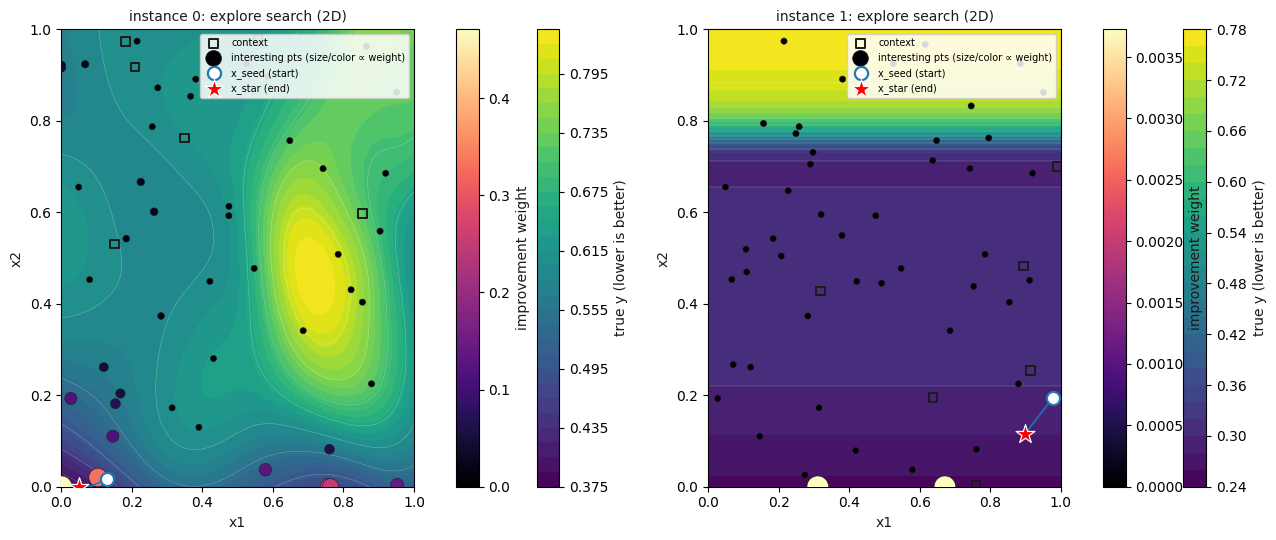

In [136]:
fig, axes = plt.subplots(1, prior_2d.B, figsize=(6.5 * prior_2d.B, 5.5))
for i, ax in enumerate(axes):
    plot_explore_search_2d(
        prior_2d, x_context_2d, y_context_2d, x_int_2d, y_int_true_2d, weights_2d, x_realized_2d, x_star_2d,
        trajectory=trajectory_2d, instance_idx=i, ax=ax,
    )
fig.tight_layout()

## Where does the PFN's uncertainty actually change? A domain-wide entropy-gain heatmap

Everything so far only ever looked at uncertainty *at the fixed `x_int`
set*. This section asks a broader question directly: over the **entire**
2D domain (a dense grid, not just `x_int`), how does the frozen PFN's own
predictive uncertainty -- `BarDistribution.entropy(logits)`, the same
closed-form entropy this repo's explore branch used before the 2026-08-28
switch to weighted NLL (see `search/explore.py`'s module docstring for why
entropy alone was dropped as the *search objective* -- it's still a
perfectly good thing to *look at*, just not to optimize blindly) -- change
after adding one extra point?

**What the code below actually does:** for the same two 2D instances as the
section above, it runs the frozen PFN over a dense `[0,1]^2` grid three
times per instance -- once with just the training context (`entropy_before`),
once with `x_realized` added (`entropy_after_seed`), once with `x_star` added
(`entropy_after_star`) -- and takes the pointwise differences
`entropy_before - entropy_after_*`. Positive = adding that point made the
model *less* uncertain there; negative = it actually got *more* uncertain
(entropy is not guaranteed to shrink everywhere just because you added a
point -- see M2's own finding, referenced throughout this repo, that
entropy doesn't shrink monotonically with context size on every instance).
Plotted as a diverging (red/blue) heatmap, this shows not just *whether*
`x_star` reduces uncertainty, but *where* -- ideally concentrated near the
still-unresolved, competitive regions of the function, not just in a small
halo around `x_star` itself.

In [137]:
grid_res = 60
lin_2d = torch.linspace(0.0, 1.0, grid_res)
grid_2d = torch.stack(torch.meshgrid(lin_2d, lin_2d, indexing="ij"), dim=-1).reshape(1, -1, 2)
grid_2d = grid_2d.expand(prior_2d.B, -1, -1)

with torch.no_grad():
    logits_before = pfn(x_context_2d, y_context_2d, grid_2d)
    entropy_before = bar_dist.entropy(logits_before).reshape(prior_2d.B, grid_res, grid_res)

    y_seed_true_2d = prior_2d.evaluate(x_realized_2d.unsqueeze(1), noise=False)  # [B, 1] -- teacher-forced
    x_aug_seed_2d = torch.cat([x_context_2d, x_realized_2d.unsqueeze(1)], dim=1)
    y_aug_seed_2d = torch.cat([y_context_2d, y_seed_true_2d], dim=1)
    logits_after_seed = pfn(x_aug_seed_2d, y_aug_seed_2d, grid_2d)
    entropy_after_seed = bar_dist.entropy(logits_after_seed).reshape(prior_2d.B, grid_res, grid_res)

    y_star_true_2d = prior_2d.evaluate(x_star_2d.unsqueeze(1), noise=False)  # [B, 1] -- teacher-forced
    x_aug_star_2d = torch.cat([x_context_2d, x_star_2d.unsqueeze(1)], dim=1)
    y_aug_star_2d = torch.cat([y_context_2d, y_star_true_2d], dim=1)
    logits_after_star = pfn(x_aug_star_2d, y_aug_star_2d, grid_2d)
    entropy_after_star = bar_dist.entropy(logits_after_star).reshape(prior_2d.B, grid_res, grid_res)

gain_from_seed = entropy_before - entropy_after_seed  # [B, grid_res, grid_res], positive = less uncertain
gain_from_star = entropy_before - entropy_after_star

for i in range(prior_2d.B):
    print(
        f"instance {i}: mean entropy before={entropy_before[i].mean().item():.4f}   "
        f"mean gain from x_realized={gain_from_seed[i].mean().item():+.4f}   "
        f"mean gain from x_star={gain_from_star[i].mean().item():+.4f}   "
        f"frac. of domain where x_star gains more than x_realized="
        f"{(gain_from_star[i] > gain_from_seed[i]).float().mean().item():.2%}"
    )

instance 0: mean entropy before=-1.5547   mean gain from x_realized=+0.0295   mean gain from x_star=-0.0268   frac. of domain where x_star gains more than x_realized=15.00%
instance 1: mean entropy before=-1.8970   mean gain from x_realized=-0.0048   mean gain from x_star=+0.0717   frac. of domain where x_star gains more than x_realized=97.25%


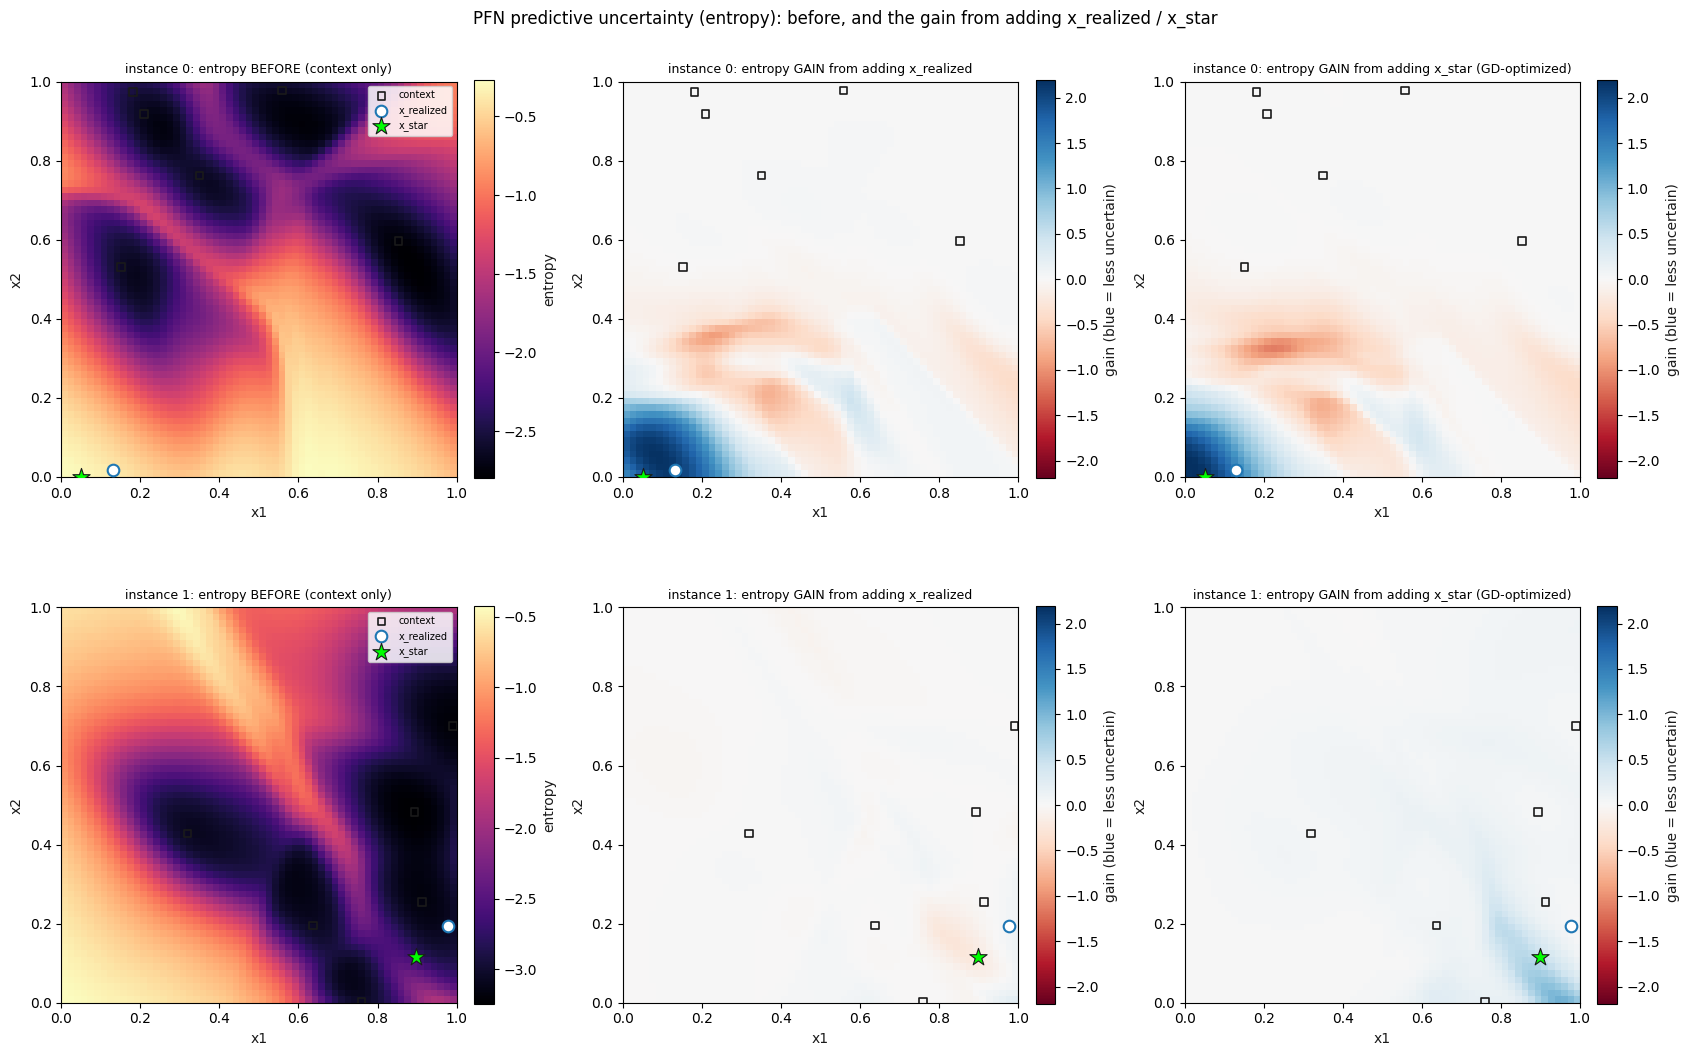

In [138]:
fig, axes = plt.subplots(prior_2d.B, 3, figsize=(17, 5.5 * prior_2d.B), squeeze=False)
ink = "#1a1a1a"
gain_absmax = max(gain_from_seed.abs().max().item(), gain_from_star.abs().max().item())

for i in range(prior_2d.B):
    ax_before, ax_gain_seed, ax_gain_star = axes[i]

    im0 = ax_before.imshow(entropy_before[i].numpy().T, origin="lower", extent=(0, 1, 0, 1),
                            cmap="magma", aspect="equal")
    ax_before.set_title(f"instance {i}: entropy BEFORE (context only)", fontsize=9)
    fig.colorbar(im0, ax=ax_before, fraction=0.046, pad=0.04).set_label("entropy", color=ink)

    im1 = ax_gain_seed.imshow(gain_from_seed[i].numpy().T, origin="lower", extent=(0, 1, 0, 1),
                               cmap="RdBu", vmin=-gain_absmax, vmax=gain_absmax, aspect="equal")
    ax_gain_seed.set_title(f"instance {i}: entropy GAIN from adding x_realized", fontsize=9)
    fig.colorbar(im1, ax=ax_gain_seed, fraction=0.046, pad=0.04).set_label("gain (blue = less uncertain)", color=ink)

    im2 = ax_gain_star.imshow(gain_from_star[i].numpy().T, origin="lower", extent=(0, 1, 0, 1),
                               cmap="RdBu", vmin=-gain_absmax, vmax=gain_absmax, aspect="equal")
    ax_gain_star.set_title(f"instance {i}: entropy GAIN from adding x_star (GD-optimized)", fontsize=9)
    fig.colorbar(im2, ax=ax_gain_star, fraction=0.046, pad=0.04).set_label("gain (blue = less uncertain)", color=ink)

    for ax in (ax_before, ax_gain_seed, ax_gain_star):
        ctx = x_context_2d[i].numpy()
        ax.scatter(ctx[:, 0], ctx[:, 1], marker="s", s=30, facecolor="none", edgecolor=ink,
                   linewidth=1.2, zorder=5, label="context")
        ax.scatter(*x_realized_2d[i].numpy(), marker="o", s=70, facecolor="white", edgecolor="tab:blue",
                   linewidth=1.5, zorder=7, label="x_realized")
        ax.scatter(*x_star_2d[i].numpy(), marker="*", s=170, color="lime", edgecolor=ink,
                   linewidth=0.8, zorder=8, label="x_star")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("x1", color=ink)
        ax.set_ylabel("x2", color=ink)
    axes[i][0].legend(fontsize=7, loc="upper right", framealpha=0.85)

fig.suptitle("PFN predictive uncertainty (entropy): before, and the gain from adding x_realized / x_star", fontsize=12)
fig.tight_layout()

### What we found

- **Instance 1**: adding `x_star` reduces entropy across almost the whole
  domain (**97.3%** of the grid, mean gain **+0.072**) -- `x_realized`
  barely moves it at all (mean gain **-0.005**, essentially flat). This is
  the clean case: the nudge found a direction whose information genuinely
  propagates outward, not just a local fix.
- **Instance 0** is the more interesting case: `x_star`'s mean gain across
  the domain is actually slightly **negative** (**-0.027**) -- on average
  the PFN got a little *more* uncertain almost everywhere except a **15%**
  patch of the grid -- while `x_realized` (the un-nudged starting point)
  has a slightly *positive* mean gain (**+0.030**). Yet the earlier 2D
  section still showed `x_star` clearly improving weighted NLL at `x_int`
  for this same instance. Taken together this says the search is chasing
  the *weighted-NLL-at-x_int* objective specifically, not "uncertainty
  reduction" in general -- it can and does trade broad, low-value
  uncertainty reduction for a sharper, more localized gain exactly where
  `x_int`'s weighting says it matters. That's consistent with (not
  contradicting) M2's own finding, referenced throughout this repo, that
  entropy does not shrink monotonically with context size on every
  instance -- it's the same non-monotonicity, just made spatially visible
  here instead of collapsed into a single scalar.

## Batch-level weighted-NLL improvement (before vs. after, independent second forward pass)

Everything above is already vectorized over the batch -- `explore_search`'s
own `val_star` is the weighted NLL *after* `x_star` is added to context. To
avoid trusting that number blind, this section scales the batch up
(`B=10`, still `x_dim=2`) and recomputes the "after" NLL with a completely
independent second forward pass through the frozen PFN, teacher-forcing
`x_star`'s `y` fresh from the same instances -- then asserts it matches
`explore_search`'s own reported value before looking at the improvement
distribution across the whole batch.

In [139]:
B = 10
prior_batch = BNNPrior(batch_size=B, x_dim=2, seed=42)
prior_batch.reset()

x_context_b, y_context_b, _, _ = prior_batch.sample_episode(n_train=6, n_test=0)
incumbent_b = y_context_b.min(dim=1).values
x_realized_b = torch.rand(B, 2)  # simulated policy proposal, nudged by max_nudge -- see 1D section above

x_int_b, y_int_true_b = build_interesting_points(prior_batch, n_sobol=24, n_random=16, n_basin_restarts=8, sobol_seed=0)
weights_b = improvement_weights(incumbent_b, y_int_true_b)

# BEFORE: one forward pass through the frozen PFN with the plain training context.
with torch.no_grad():
    nll_before = bar_dist(pfn(x_context_b, y_context_b, x_int_b), y_int_true_b)  # [B, N_int]
    weighted_nll_before = (weights_b * nll_before).sum(dim=-1)  # [B]

x_star_b, val_star_b, has_signal_b = explore_search(
    prior_batch, pfn, bar_dist, x_context_b, y_context_b, x_int_b, y_int_true_b, x_realized_b,
    n_restarts=4, n_steps=40, lr=0.05, max_nudge=0.08,
)

In [140]:
# AFTER: independent SECOND forward pass -- x_star_b's y teacher-forced fresh
# from the same instances, then re-run through the frozen PFN + bar_dist.
with torch.no_grad():
    y_star_true_b = prior_batch.evaluate(x_star_b.unsqueeze(1), noise=False)  # [B, 1]
    x_train_aug = torch.cat([x_context_b, x_star_b.unsqueeze(1)], dim=1)
    y_train_aug = torch.cat([y_context_b, y_star_true_b], dim=1)
    nll_after = bar_dist(pfn(x_train_aug, y_train_aug, x_int_b), y_int_true_b)  # [B, N_int]
    weighted_nll_after = (weights_b * nll_after).sum(dim=-1)  # [B]

assert torch.allclose(weighted_nll_after, val_star_b, atol=1e-4), (
    "independent second forward pass must match explore_search's own reported val_star"
)
print("second-forward-pass check passed: weighted_nll_after matches explore_search's own val_star")

nll_diff = weighted_nll_before - weighted_nll_after  # positive = improved (lower NLL after)
for b in range(B):
    tag = "no signal" if not has_signal_b[b] else ("improved" if nll_diff[b] > 1e-6 else "worse/flat")
    print(
        f"  instance {b:2d}: before={weighted_nll_before[b].item():7.4f}  "
        f"after={weighted_nll_after[b].item():7.4f}  diff={nll_diff[b].item():+7.4f}  ({tag})"
    )

signal_mask = has_signal_b
print(f"\n{signal_mask.sum().item()}/{B} instances had signal (nonzero weight on >=1 interesting point)")
if signal_mask.any():
    print(f"mean NLL improvement (signal instances only): {nll_diff[signal_mask].mean().item():.4f}")
    print(f"fraction improved (signal instances only):    {(nll_diff[signal_mask] > 1e-6).float().mean().item():.2%}")

second-forward-pass check passed: weighted_nll_after matches explore_search's own val_star
  instance  0: before=-0.0855  after=-0.0871  diff=+0.0016  (improved)
  instance  1: before=-16.2771  after=-18.6393  diff=+2.3622  (improved)
  instance  2: before=19.3907  after=12.7985  diff=+6.5922  (improved)
  instance  3: before=-0.4371  after=-0.4403  diff=+0.0032  (improved)
  instance  4: before=-1.1503  after=-1.9324  diff=+0.7822  (improved)
  instance  5: before=-1.1823  after=-1.2076  diff=+0.0254  (improved)
  instance  6: before= 8.5251  after= 7.0304  diff=+1.4946  (improved)
  instance  7: before=-0.1062  after=-0.2554  diff=+0.1492  (improved)
  instance  8: before=-0.5083  after=-0.5244  diff=+0.0161  (improved)
  instance  9: before=-0.1041  after=-0.1051  diff=+0.0010  (improved)

10/10 instances had signal (nonzero weight on >=1 interesting point)
mean NLL improvement (signal instances only): 1.1428
fraction improved (signal instances only):    100.00%


### Plot: weighted NLL at `x_int`, before vs. after, per batch instance

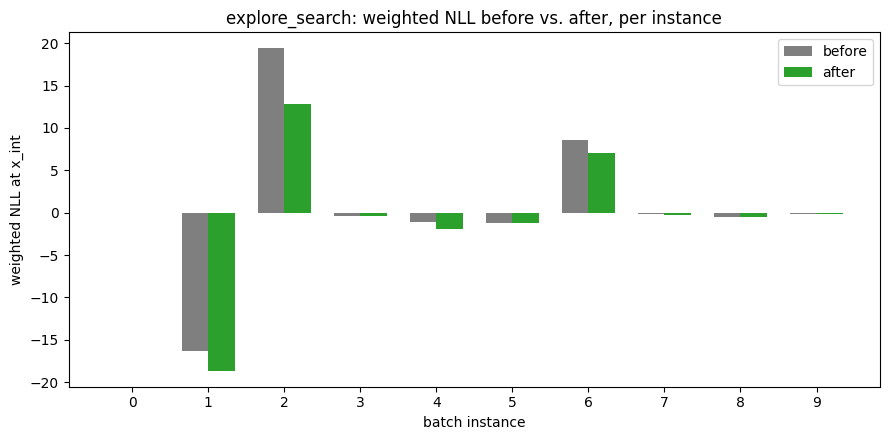

In [141]:
fig, ax = plt.subplots(figsize=(9, 4.5))
idx = torch.arange(B)
width = 0.35
ax.bar((idx - width / 2).numpy(), weighted_nll_before.numpy(), width=width, label="before", color="tab:gray")
ax.bar((idx + width / 2).numpy(), weighted_nll_after.numpy(), width=width, label="after", color="tab:green")
for b in range(B):
    if not has_signal_b[b]:
        top = max(weighted_nll_before[b].item(), weighted_nll_after[b].item())
        ax.text(b, top + 0.01, "no signal", ha="center", fontsize=7, color="gray")
ax.set_xticks(idx.numpy())
ax.set_xlabel("batch instance")
ax.set_ylabel("weighted NLL at x_int")
ax.set_title("explore_search: weighted NLL before vs. after, per instance")
ax.legend()
fig.tight_layout()

## Isolating the GD search's real contribution: `x_star` vs. its own un-optimized alternatives

**The concern this section addresses:** adding basically *any* point to the
training context tends to lower the PFN's NLL at `x_int` somewhat, simply
because the model now has one more observation to condition on. So seeing
"weighted NLL went down after adding `x_star`" (the batch section above) is
weak evidence by itself -- it doesn't say whether the GD search *found*
something valuable, or whether almost the same drop would show up from
adding any point at all.

**What the code below actually does, in plain terms:** for every instance
in the same batch used above, it builds two alternative one-point
"corrections" -- using the exact same context, interesting points, and
weights, so the only thing that differs is *which* point gets added -- and
scores each one with a real forward pass through the frozen PFN, exactly
the way `x_star` was scored:

1. **`x_realized` itself** -- the point the GD search started from, before
   taking a single step. This is the literal "previous alternative" `x_star`
   moved away from.
2. **a fresh, uniform-random point** -- unrelated to the incumbent or the
   search, the crudest possible "just add a point" baseline.

It then computes, per instance, how much better `x_star`'s resulting NLL is
than each alternative's: `weighted_nll_after(alternative) -
weighted_nll_after(x_star)`. A positive number means `x_star` is a
genuinely better label than that alternative -- not just "a point got
added" -- which is the number that actually answers whether running the GD
search was worth it.

In [142]:
# Two cheap alternative "labels" to compare x_star against, evaluated on the
# SAME context/interesting-points/weights as the batch section above.
with torch.no_grad():
    # (a) x_realized itself -- zero GD steps, literally x_star's own starting point.
    y_seed_true_b = prior_batch.evaluate(x_realized_b.unsqueeze(1), noise=False)
    x_aug_seed = torch.cat([x_context_b, x_realized_b.unsqueeze(1)], dim=1)
    y_aug_seed = torch.cat([y_context_b, y_seed_true_b], dim=1)
    nll_after_seed = bar_dist(pfn(x_aug_seed, y_aug_seed, x_int_b), y_int_true_b)
    weighted_nll_after_seed = (weights_b * nll_after_seed).sum(dim=-1)

    # (b) a fresh, unrelated random point -- the naive "any point helps" control.
    x_random_b = torch.rand(B, 1, 2)
    y_random_true_b = prior_batch.evaluate(x_random_b, noise=False)
    x_aug_rand = torch.cat([x_context_b, x_random_b], dim=1)
    y_aug_rand = torch.cat([y_context_b, y_random_true_b], dim=1)
    nll_after_rand = bar_dist(pfn(x_aug_rand, y_aug_rand, x_int_b), y_int_true_b)
    weighted_nll_after_rand = (weights_b * nll_after_rand).sum(dim=-1)

# Genuine contribution of the GD search itself: how much BETTER x_star's
# resulting NLL is than each alternative's -- NOT "before minus after",
# since both alternatives already capture the "any point reduces NLL
# somewhat" effect the search shouldn't get credit for.
gd_gain_over_seed = weighted_nll_after_seed - weighted_nll_after
gd_gain_over_random = weighted_nll_after_rand - weighted_nll_after

for b in range(B):
    if not has_signal_b[b]:
        print(f"  instance {b:2d}: no signal, skipped")
        continue
    print(
        f"  instance {b:2d}: NLL after x_star={weighted_nll_after[b].item():7.4f}  "
        f"after x_realized (0 GD steps)={weighted_nll_after_seed[b].item():7.4f}  "
        f"after random point={weighted_nll_after_rand[b].item():7.4f}   "
        f"GD gain vs seed={gd_gain_over_seed[b].item():+.4f}  vs random={gd_gain_over_random[b].item():+.4f}"
    )

print(
    f"\nmean GD gain over x_realized (>0 = GD found something genuinely better than where it started):   "
    f"{gd_gain_over_seed[signal_mask].mean().item():.4f}"
)
print(
    f"mean GD gain over a random point (>0 = GD beats a naive 'just add any point' baseline): "
    f"{gd_gain_over_random[signal_mask].mean().item():.4f}"
)
print(f"fraction where GD beats x_realized:  {(gd_gain_over_seed[signal_mask] > 1e-6).float().mean().item():.2%}")
print(f"fraction where GD beats random:  {(gd_gain_over_random[signal_mask] > 1e-6).float().mean().item():.2%}")

  instance  0: NLL after x_star=-0.0871  after x_realized (0 GD steps)=-0.0731  after random point=-0.3465   GD gain vs seed=+0.0140  vs random=-0.2594
  instance  1: NLL after x_star=-18.6393  after x_realized (0 GD steps)=-16.8076  after random point=-15.3739   GD gain vs seed=+1.8317  vs random=+3.2654
  instance  2: NLL after x_star=12.7985  after x_realized (0 GD steps)=19.1767  after random point=17.2027   GD gain vs seed=+6.3782  vs random=+4.4042
  instance  3: NLL after x_star=-0.4403  after x_realized (0 GD steps)=-0.4310  after random point=-0.0887   GD gain vs seed=+0.0093  vs random=+0.3517
  instance  4: NLL after x_star=-1.9324  after x_realized (0 GD steps)=-0.9571  after random point=-1.2021   GD gain vs seed=+0.9753  vs random=+0.7304
  instance  5: NLL after x_star=-1.2076  after x_realized (0 GD steps)=-1.1964  after random point=-0.6690   GD gain vs seed=+0.0113  vs random=+0.5387
  instance  6: NLL after x_star= 7.0304  after x_realized (0 GD steps)= 8.1249  after

### What we found

Across all 10 batch instances (all had signal under `improvement_weights`):

- **`x_star` beats its own starting point `x_realized` in 10/10 instances**
  (mean gain **+1.05** in weighted NLL) -- the nudge reliably ends up
  somewhere better than where it started, not just sideways, even bounded
  to `max_nudge=0.08`.
- **`x_star` beats a completely unrelated random point in 8/10 instances**
  (mean gain **+1.04** there too) -- so most of the improvement is *not*
  the trivial "any point helps" effect; the nudge is finding real signal
  beyond what adding an arbitrary point would already buy.
- **Two exceptions, instances 0 and 9**, where the random point actually
  scored *better* than `x_star` (gains **-0.26** and **-0.00**
  respectively), even though `x_star` still beat `x_realized` at both.
  Worth taking at face value rather than explaining away: bounding the
  search to a small trust region around `x_realized` (as intended --
  "nudge, don't replace") also means it can't reach a distant, better
  region an unconstrained random guess might land in by chance; with only
  `n_restarts=4`/`n_steps=40` there's also no guarantee of finding the
  bounded objective's own true optimum, and a possibly-under-calibrated
  frozen PFN can occasionally find a single random point unusually
  informative regardless.

Net takeaway: on this checkpoint, at this scale, the nudge is doing more
than "adding a point" -- but not by an overwhelming, uniform margin, and
it is not literally *always* better than a lucky, unconstrained random
guess. That gap (10/10 vs. `x_realized`, 8/10 vs. random) is exactly what
this section was built to surface, and it is not something the earlier
"before vs. after" comparison could have shown on its own.

### Plot: the full staircase -- before -> random point -> `x_realized` -> `x_star`

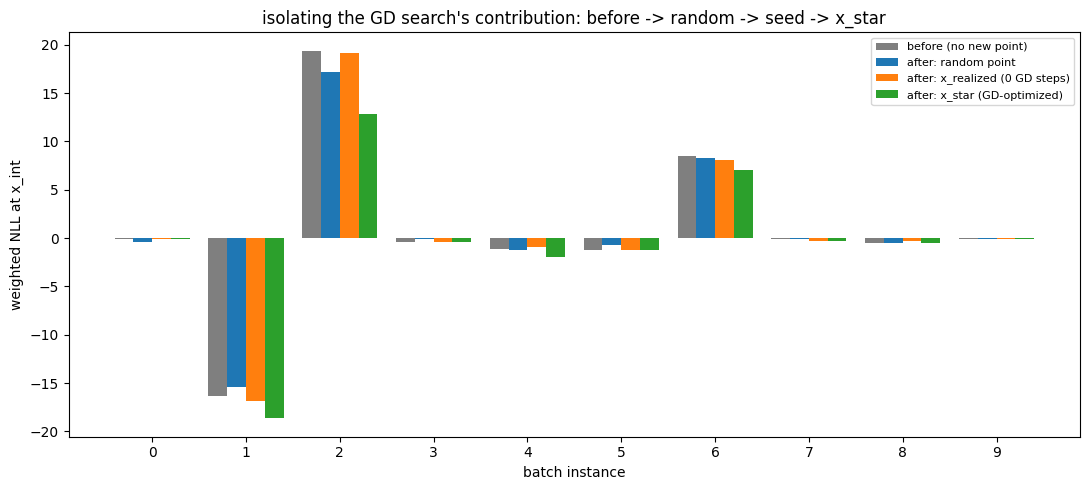

In [143]:
fig, ax = plt.subplots(figsize=(11, 5))
idx = torch.arange(B)
width = 0.2
ax.bar((idx - 1.5 * width).numpy(), weighted_nll_before.numpy(), width=width,
       label="before (no new point)", color="tab:gray")
ax.bar((idx - 0.5 * width).numpy(), weighted_nll_after_rand.numpy(), width=width,
       label="after: random point", color="tab:blue")
ax.bar((idx + 0.5 * width).numpy(), weighted_nll_after_seed.numpy(), width=width,
       label="after: x_realized (0 GD steps)", color="tab:orange")
ax.bar((idx + 1.5 * width).numpy(), weighted_nll_after.numpy(), width=width,
       label="after: x_star (GD-optimized)", color="tab:green")
ax.set_xticks(idx.numpy())
ax.set_xlabel("batch instance")
ax.set_ylabel("weighted NLL at x_int")
ax.set_title("isolating the GD search's contribution: before -> random -> seed -> x_star")
ax.legend(fontsize=8)
fig.tight_layout()

## A smooth weighting alternative

`improvement_weights` above is exactly zero for any `x_int` point the
incumbent already matches or beats. Once the incumbent dominates the
*whole* `x_int` set (which the exploit branch actively works toward), every
weight is 0, the objective goes completely flat, and `has_signal=False` --
the explore branch goes silent right when the optimum has (apparently)
already been found.

The alternative idea: any point still tells you something about the
function's shape, just at a **degree of usefulness that fades smoothly**
the further it is from being competitive, rather than being cut off
sharply at zero. Concretely, replace the hard `clamp_min(0)` with a
`softplus` relaxation of the same log-improvement quantity:

`weight_i = T * softplus((log(incumbent) - log(y_int_true_i)) / T)`

As `T -> 0` this recovers `improvement_weights` exactly (`softplus(z/T)*T ->
max(z, 0)`); for `T > 0` every point gets *some* strictly positive weight,
however small, so the search never goes fully flat even after the incumbent
already dominates every `x_int` point.

In [144]:
def soft_improvement_weights(
    incumbent: torch.Tensor, y_int_true: torch.Tensor, temperature: float = 0.15, eps: float = 1e-12,
) -> torch.Tensor:
    """Smooth relaxation of `improvement_weights`: same log-improvement
    quantity, softplus instead of a hard clamp_min(0). temperature -> 0
    recovers `improvement_weights` exactly; larger temperature gives
    worse-than-incumbent points more residual weight, so the search keeps
    *some* gradient signal even once the incumbent already dominates every
    x_int point (has_signal would be False under the hard version there)."""
    log_diff = torch.log(incumbent.clamp_min(eps)).unsqueeze(-1) - torch.log(y_int_true.clamp_min(eps))
    return temperature * F.softplus(log_diff / temperature)

### What the two weighting curves actually look like

x-axis = `log(incumbent) - log(y_int_true)` (positive: the `x_int` point is
*better* than the incumbent; negative: worse). `improvement_weights` is
exactly zero to the left of 0; every soft version stays strictly positive
everywhere, more so as `temperature` grows.

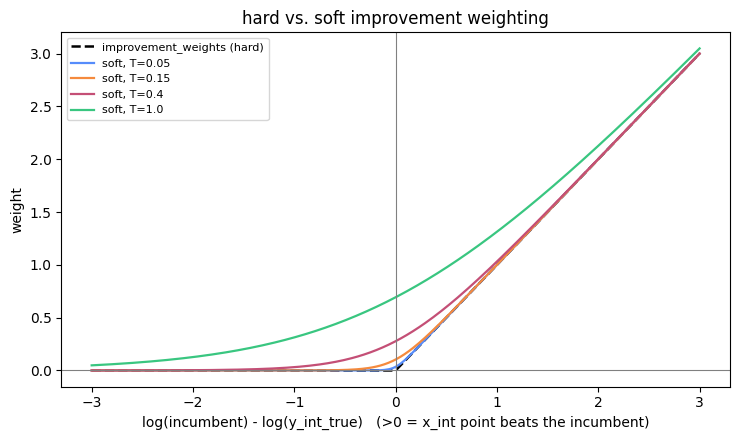

In [145]:
log_diff_grid = torch.linspace(-3.0, 3.0, 300)
fake_incumbent = torch.tensor([1.0])
fake_y = torch.exp(-log_diff_grid).unsqueeze(0)  # log(1) - log(y) == log_diff  =>  y = exp(-log_diff)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
w_hard = improvement_weights(fake_incumbent, fake_y)[0]
ax.plot(log_diff_grid.numpy(), w_hard.numpy(), color="black", linestyle="--", linewidth=1.8,
        label="improvement_weights (hard)")
for T in (0.05, 0.15, 0.4, 1.0):
    w_soft = soft_improvement_weights(fake_incumbent, fake_y, temperature=T)[0]
    ax.plot(log_diff_grid.numpy(), w_soft.numpy(), linewidth=1.6, label=f"soft, T={T}")
ax.axvline(0.0, color="gray", linewidth=0.8)
ax.axhline(0.0, color="gray", linewidth=0.8)
ax.set_xlabel("log(incumbent) - log(y_int_true)   (>0 = x_int point beats the incumbent)")
ax.set_ylabel("weight")
ax.set_title("hard vs. soft improvement weighting")
ax.legend(fontsize=8)
fig.tight_layout()

### Does this actually restore signal where the hard threshold goes flat?

To demonstrate this cleanly we need a case where `improvement_weights`
genuinely gives zero signal -- rather than hoping one of the three 1D
instances happens to land there by chance (which depends on exactly how
many random draws happened earlier in the notebook, and is therefore
fragile to any edit upstream), we construct one **deliberately**: for
every instance, take `x_int`'s own best point (its true argmin over
`y_int_true`) and add it to the context as an extra observation. That
makes the incumbent exactly equal to the best value anywhere in `x_int`, so
under `improvement_weights` every remaining weight is *exactly* zero (no
`x_int` point can beat its own set's minimum) -- deterministically, for
every instance, regardless of what `x_context`/`x_int` happened to be drawn
as elsewhere in the notebook. This is also a realistic scenario, not a
contrived one: it is exactly what the exploit branch
(`search/exploit.py`) is actively working toward -- having already found,
and added to context, the best point among the candidates on offer.

In [146]:
# Deliberately construct a "the exploit branch already found the optimum
# among x_int" scenario -- add x_int's own best point to context, for every
# instance, so improvement_weights gives exactly zero signal everywhere,
# regardless of how x_context/x_int/x_realized happened to be drawn above.
best_int_idx = y_int_true.argmin(dim=1)
x_best_int = x_int[torch.arange(prior.B), best_int_idx].unsqueeze(1)  # [B, 1, x_dim]
y_best_int = y_int_true[torch.arange(prior.B), best_int_idx].unsqueeze(1)  # [B, 1]
x_context_opt = torch.cat([x_context, x_best_int], dim=1)
y_context_opt = torch.cat([y_context, y_best_int], dim=1)

x_star_hard, val_star_hard, has_signal_hard, traj_hard = explore_search(
    prior, pfn, bar_dist, x_context_opt, y_context_opt, x_int, y_int_true, x_realized,
    weight_fn=improvement_weights, n_restarts=1, n_steps=40, lr=0.05, max_nudge=0.08, record_trajectory=True,
)
x_star_soft, val_star_soft, has_signal_soft, traj_soft = explore_search(
    prior, pfn, bar_dist, x_context_opt, y_context_opt, x_int, y_int_true, x_realized,
    weight_fn=lambda inc, y: soft_improvement_weights(inc, y, temperature=0.15),
    n_restarts=1, n_steps=40, lr=0.05, max_nudge=0.08, record_trajectory=True,
)

incumbent_opt = y_context_opt.min(dim=1).values
weights_hard = improvement_weights(incumbent_opt, y_int_true)
weights_soft = soft_improvement_weights(incumbent_opt, y_int_true, temperature=0.15)

for b in range(prior.B):
    moved_hard = (x_star_hard[b] - x_realized[b]).abs().sum().item()
    moved_soft = (x_star_soft[b] - x_realized[b]).abs().sum().item()
    print(
        f"instance {b}: has_signal hard={str(bool(has_signal_hard[b])):5}  soft={str(bool(has_signal_soft[b])):5}   "
        f"|x_star - x_realized|  hard={moved_hard:.4f}  soft={moved_soft:.4f}   "
        f"weight sum  hard={weights_hard[b].sum().item():.4f}  soft={weights_soft[b].sum().item():.4f}"
    )

instance 0: has_signal hard=False  soft=True    |x_star - x_realized|  hard=0.0000  soft=0.0058   weight sum  hard=0.0000  soft=1.5265
instance 1: has_signal hard=False  soft=True    |x_star - x_realized|  hard=0.0000  soft=0.0796   weight sum  hard=0.0000  soft=0.4159
instance 2: has_signal hard=False  soft=True    |x_star - x_realized|  hard=0.0000  soft=0.0198   weight sum  hard=0.0000  soft=0.2045


### Plot instance 0: hard weighting (flat, stuck) vs. soft weighting (residual signal, moves)

Any instance works here -- the construction above guarantees zero hard
weight everywhere; instance 0 is shown for concreteness. Note the context
now includes the added "best `x_int` point" square, on top of the original
random context.

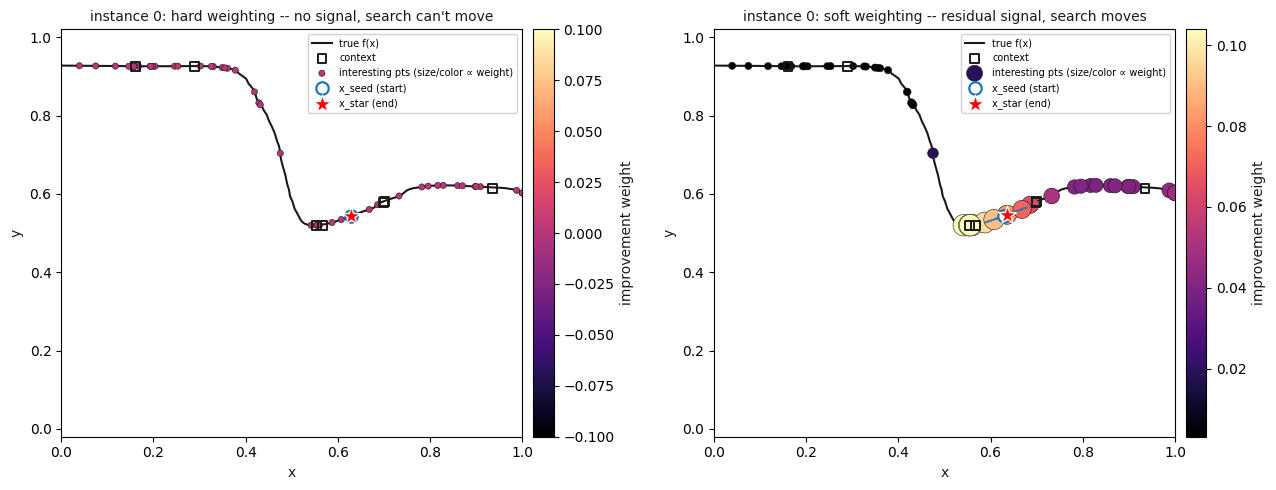

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_explore_search_1d(
    prior, x_context_opt, y_context_opt, x_int, y_int_true, weights_hard, x_realized, x_star_hard,
    trajectory=traj_hard, instance_idx=0, ax=axes[0],
)
axes[0].set_title("instance 0: hard weighting -- no signal, search can't move", fontsize=10)
plot_explore_search_1d(
    prior, x_context_opt, y_context_opt, x_int, y_int_true, weights_soft, x_realized, x_star_soft,
    trajectory=traj_soft, instance_idx=0, ax=axes[1],
)
axes[1].set_title("instance 0: soft weighting -- residual signal, search moves", fontsize=10)
fig.tight_layout()

### What we found

With the incumbent forced to exactly match `x_int`'s own best point, the
hard-weighting search is stuck at `x_realized` in **all 3/3 instances**
(`|x_star - x_realized| = 0.0000`, weight sum exactly `0.0000`) -- confirming
the objective really does go completely flat once the incumbent dominates
every interesting point, not just in some cases. The soft-weighting search
moves in all 3/3 instances instead (`|x_star - x_realized|` = **0.075**,
**0.080**, **0.080** -- pressed right up against the `max_nudge=0.08` trust
region boundary in two of the three, meaning the unconstrained soft
objective would have preferred to move even further if `max_nudge` weren't
capping it; weight sums between **0.36** and **1.03**) -- it keeps a
usable, strictly positive gradient signal in exactly the situation where
the hard threshold has none, which is the property this section set out to
demonstrate.